In [1]:
#session 16 1
tp = 50
tn = 120
fp = 10
fn = 20

total_samples = tp + tn + fp + fn
accuracy = (tp + tn) / total_samples
precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1_score = 2 * (precision * recall) / (precision + recall)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1_score:.4f}")

Task 1: Spam Filter Confusion Matrix Calculations

Accuracy: 0.8500
Precision: 0.8333
Recall: 0.7143
F1 Score: 0.7692


In [4]:
#session 16 2
def print_confusion_matrix(tp, tn, fp, fn):
    print("Confusion Matrix:")
    print(f"┌───────────────────┐")
    print(f"│ Actual     Predicted│")
    print(f"│            ─────────│")
    print(f"│          │ Positive │ Negative│")
    print(f"├──────────┼──────────┼─────────┤")
    print(f"│ Positive │ {tp:<8} │ {fn:<7} │")
    print(f"│ Negative │ {fp:<8} │ {tn:<7} │")
    print(f"└──────────┴──────────┴─────────┘")

# Demonstration of the function using spam filter values
print_confusion_matrix(50, 120, 10, 20)


Task 2: Confusion Matrix Printing Function

Confusion Matrix:
┌───────────────────┐
│ Actual     Predicted│
│            ─────────│
│          │ Positive │ Negative│
├──────────┼──────────┼─────────┤
│ Positive │ 50       │ 20      │
│ Negative │ 10       │ 120     │
└──────────┴──────────┴─────────┘


In [2]:
#session 16 3
tp_fake_news = 60
fn_fake_news = 30
tn_fake_news = 120
fp_fake_news = 10

precision_fake_news = tp_fake_news / (tp_fake_news + fp_fake_news)
recall_fake_news = tp_fake_news / (tp_fake_news + fn_fake_news)

print(f"Precision for Fake News Model: {precision_fake_news:.4f}")
print(f"Recall for Fake News Model: {recall_fake_news:.4f}")


Task 3: Fake News Detection Model Precision and Recall

Precision for Fake News Model: 0.8571
Recall for Fake News Model: 0.6667


In [3]:
#session 16 4
tp_fraud = 40
tn_fraud = 150
fp_fraud = 20
fn_fraud = 10

precision_fraud = tp_fraud / (tp_fraud + fp_fraud)
recall_fraud = tp_fraud / (tp_fraud + fn_fraud)
f1_score_fraud = 2 * (precision_fraud * recall_fraud) / (precision_fraud + recall_fraud)

print(f"F1 Score for Fraud Detection Model: {f1_score_fraud:.4f}")
print("The F1 score provides a balanced measure of a model's precision and recall, especially useful for imbalanced datasets.")


Task 4: Food Delivery Fraud Detection F1 Score

F1 Score for Fraud Detection Model: 0.7273
The F1 score provides a balanced measure of a model's precision and recall, especially useful for imbalanced datasets.


In [ ]:
#session 17
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_curve, auc, precision_recall_curve,
    log_loss, accuracy_score, roc_auc_score
)

X, y = make_classification(
    n_samples=10000, n_features=20, n_informative=10, n_redundant=5,
    weights=[0.99, 0.01], flip_y=0, random_state=42, n_clusters_per_class=1
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

model = LogisticRegression(solver='liblinear', random_state=42)
model.fit(X_train, y_train)

y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred_class = model.predict(X_test)

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [ ]:
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
pr_auc = auc(recall, precision)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='blue', lw=2, label=f'Precision-Recall curve (AUC = {pr_auc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.legend(loc="lower left")
plt.grid(True)
plt.show()

In [ ]:
logloss = log_loss(y_test, y_pred_proba)
print(f"Log Loss: {logloss:.4f}")

In [ ]:
pos_indices = np.where(y_test == 1)[0]
neg_indices = np.where(y_test == 0)[0]

num_pos_new = len(pos_indices)
num_neg_target = min(len(neg_indices), 49 * num_pos_new)

np.random.seed(42)
selected_neg_indices = np.random.choice(neg_indices, num_neg_target, replace=False)

X_test_imbalanced = np.vstack((X_test[pos_indices], X_test[selected_neg_indices]))
y_test_imbalanced = np.concatenate((y_test[pos_indices], y_test[selected_neg_indices]))

shuffled_indices = np.random.permutation(len(y_test_imbalanced))
X_test_imbalanced = X_test_imbalanced[shuffled_indices]
y_test_imbalanced = y_test_imbalanced[shuffled_indices]

y_pred_proba_imbalanced = model.predict_proba(X_test_imbalanced)[:, 1]
y_pred_class_imbalanced = model.predict(X_test_imbalanced)

accuracy_imbalanced = accuracy_score(y_test_imbalanced, y_pred_class_imbalanced)
roc_auc_imbalanced = roc_auc_score(y_test_imbalanced, y_pred_proba_imbalanced)
logloss_imbalanced = log_loss(y_test_imbalanced, y_pred_proba_imbalanced)

print(f"Accuracy: {accuracy_imbalanced:.4f}")
print(f"AUC: {roc_auc_imbalanced:.4f}")
print(f"Log Loss: {logloss_imbalanced:.4f}")

In [5]:
#session 18
from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

iris = load_iris()
X, y = iris.data, iris.target

knn = KNeighborsClassifier(n_neighbors=5)
scores = cross_val_score(knn, X, y, cv=5)

print(f"Average accuracy (5-fold CV): {scores.mean():.4f}")

Average accuracy (5-fold CV): 0.9733


In [6]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

iris = load_iris()
X, y = iris.data, iris.target

dtc = DecisionTreeClassifier(random_state=42)
scores = cross_val_score(dtc, X, y, cv=10)

print("Accuracy for each fold (10-fold CV):")
for i, score in enumerate(scores):
    print(f"Fold {i+1}: {score:.4f}")

Accuracy for each fold (10-fold CV):
Fold 1: 1.0000
Fold 2: 0.9333
Fold 3: 1.0000
Fold 4: 0.9333
Fold 5: 0.9333
Fold 6: 0.8667
Fold 7: 0.9333
Fold 8: 0.9333
Fold 9: 1.0000
Fold 10: 1.0000


In [7]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import StratifiedKFold

iris = load_iris()
X, y = iris.data, iris.target

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

print("Class distribution in each fold (Iris dataset):")
for fold, (train_index, test_index) in enumerate(skf.split(X, y)):
    y_train_fold, y_test_fold = y[train_index], y[test_index]
    train_counts = np.bincount(y_train_fold)
    test_counts = np.bincount(y_test_fold)
    print(f"\nFold {fold+1}:")
    print(f"  Train set class counts: {train_counts}")
    print(f"  Test set class counts: {test_counts}")

Class distribution in each fold (Iris dataset):

Fold 1:
  Train set class counts: [33 33 34]
  Test set class counts: [17 17 16]

Fold 2:
  Train set class counts: [33 34 33]
  Test set class counts: [17 16 17]

Fold 3:
  Train set class counts: [34 33 33]
  Test set class counts: [16 17 17]


In [8]:
import numpy as np
from sklearn.datasets import load_wine
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

wine = load_wine()
X, y = wine.data, wine.target

rf_classifier = RandomForestClassifier(random_state=42)
cv_values = [3, 5, 10]

results = {}
for cv in cv_values:
    scores = cross_val_score(rf_classifier, X, y, cv=cv)
    results[cv] = {"mean": scores.mean(), "std": scores.std()}

print("RandomForestClassifier Accuracy (Wine dataset) for different cv values:")
for cv, data in results.items():
    print(f"cv={cv}: Mean Accuracy={data['mean']:.4f}, Std Dev={data['std']:.4f}")

RandomForestClassifier Accuracy (Wine dataset) for different cv values:
cv=3: Mean Accuracy=0.9663, Std Dev=0.0138
cv=5: Mean Accuracy=0.9721, Std Dev=0.0176
cv=10: Mean Accuracy=0.9833, Std Dev=0.0255


In [10]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

def run_kfold_cv(classifier, X, y, k_folds):
    scores = cross_val_score(classifier, X, y, cv=k_folds)
    return scores.mean(), scores.std()

# Example usage:
iris = load_iris()
X_iris, y_iris = iris.data, iris.target
knn_classifier = KNeighborsClassifier(n_neighbors=5)

mean_acc, std_acc = run_kfold_cv(knn_classifier, X_iris, y_iris, k_folds=5)
print(f"Mean Accuracy: {mean_acc:.4f}")
print(f"Standard Deviation: {std_acc:.4f}")

Mean Accuracy: 0.9733
Standard Deviation: 0.0249


In [11]:
#session 19
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Simulate a dataset for product reviews
X, y = make_classification(n_samples=1000, n_features=10, n_informative=5, n_redundant=0, n_classes=2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

rf = RandomForestClassifier(random_state=42)

param_grid = {
    'max_depth': [None, 10, 20],
    'n_estimators': [50, 100, 200]
}

grid_search = GridSearchCV(rf, param_grid, cv=3, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best accuracy score: {grid_search.best_score_:.4f}")

Best parameters: {'max_depth': None, 'n_estimators': 50}
Best accuracy score: 0.9215


In [12]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.svm import SVC
from scipy.stats import uniform, loguniform

# Simulate a dataset for Instagram post engagement
X_ig, y_ig = make_classification(n_samples=500, n_features=15, n_informative=8, n_redundant=2, n_classes=2, random_state=42)
X_ig_train, X_ig_test, y_ig_train, y_ig_test = train_test_split(X_ig, y_ig, test_size=0.3, random_state=42)

svc = SVC(random_state=42)

param_distributions = {
    'C': loguniform(1e-1, 1e2),
    'gamma': loguniform(1e-4, 1e-1)
}

random_search = RandomizedSearchCV(svc, param_distributions, n_iter=10, cv=3, scoring='accuracy', random_state=42, n_jobs=-1)
random_search.fit(X_ig_train, y_ig_train)

print(f"Best parameters: {random_search.best_params_}")
print(f"Best accuracy score: {random_search.best_score_:.4f}")

Best parameters: {'C': np.float64(1.3292918943162166), 'gamma': np.float64(0.07114476009343425)}
Best accuracy score: 0.8714


In [13]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

# Simulate an imbalanced dataset (e.g., fraud detection)
X_imb, y_imb = make_classification(n_samples=1000, n_features=10, n_informative=5, n_redundant=0, n_classes=2, weights=[0.95, 0.05], random_state=42)
X_imb_train, X_imb_test, y_imb_train, y_imb_test = train_test_split(X_imb, y_imb, test_size=0.3, random_state=42, stratify=y_imb)

# Create a pipeline with SMOTE and RandomForestClassifier
pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(random_state=42))
])

param_grid_smote = {
    'classifier__max_depth': [None, 10],
    'classifier__n_estimators': [50, 100]
}

grid_search_smote = GridSearchCV(pipeline, param_grid_smote, cv=3, scoring='f1', n_jobs=-1)
grid_search_smote.fit(X_imb_train, y_imb_train)

print(f"Best parameters with SMOTE: {grid_search_smote.best_params_}")
print(f"Best F1 score with SMOTE: {grid_search_smote.best_score_:.4f}")

Best parameters with SMOTE: {'classifier__max_depth': None, 'classifier__n_estimators': 50}
Best F1 score with SMOTE: 0.4810


In [14]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score

# Use the same imbalanced dataset setup as Task 3
X_cw, y_cw = make_classification(n_samples=1000, n_features=10, n_informative=5, n_redundant=0, n_classes=2, weights=[0.95, 0.05], random_state=42)
X_cw_train, X_cw_test, y_cw_train, y_cw_test = train_test_split(X_cw, y_cw, test_size=0.3, random_state=42, stratify=y_cw)

# Model without class_weight
rf_default = RandomForestClassifier(random_state=42)
rf_default.fit(X_cw_train, y_cw_train)
y_pred_default = rf_default.predict(X_cw_test)

acc_default = accuracy_score(y_cw_test, y_pred_default)
f1_default = f1_score(y_cw_test, y_pred_default)

print(f"--- Without class_weight='balanced' ---")
print(f"Accuracy: {acc_default:.4f}")
print(f"F1-score: {f1_default:.4f}")

# Model with class_weight='balanced'
rf_balanced = RandomForestClassifier(random_state=42, class_weight='balanced')
rf_balanced.fit(X_cw_train, y_cw_train)
y_pred_balanced = rf_balanced.predict(X_cw_test)

acc_balanced = accuracy_score(y_cw_test, y_pred_balanced)
f1_balanced = f1_score(y_cw_test, y_pred_balanced)

print(f"\n--- With class_weight='balanced' ---")
print(f"Accuracy: {acc_balanced:.4f}")
print(f"F1-score: {f1_balanced:.4f}")

--- Without class_weight='balanced' ---
Accuracy: 0.9700
F1-score: 0.6087

--- With class_weight='balanced' ---
Accuracy: 0.9633
F1-score: 0.4762


In [15]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier

wine = load_wine()
X_wine, y_wine = wine.data, wine.target
X_wine_train, X_wine_test, y_wine_train, y_wine_test = train_test_split(X_wine, y_wine, test_size=0.3, random_state=42)

rf_ai_grid = RandomForestClassifier(random_state=42)

# AI-generated parameter grid (example from an AI assistant)
param_grid_ai = {
    'n_estimators': [100, 200, 300],
    'max_features': ['sqrt', 'log2'],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

grid_search_ai = GridSearchCV(rf_ai_grid, param_grid_ai, cv=3, scoring='accuracy', n_jobs=-1)
grid_search_ai.fit(X_wine_train, y_wine_train)

print(f"AI-generated grid - Best parameters: {grid_search_ai.best_params_}")
print(f"AI-generated grid - Best accuracy score: {grid_search_ai.best_score_:.4f}")

AI-generated grid - Best parameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 100}
AI-generated grid - Best accuracy score: 0.9758


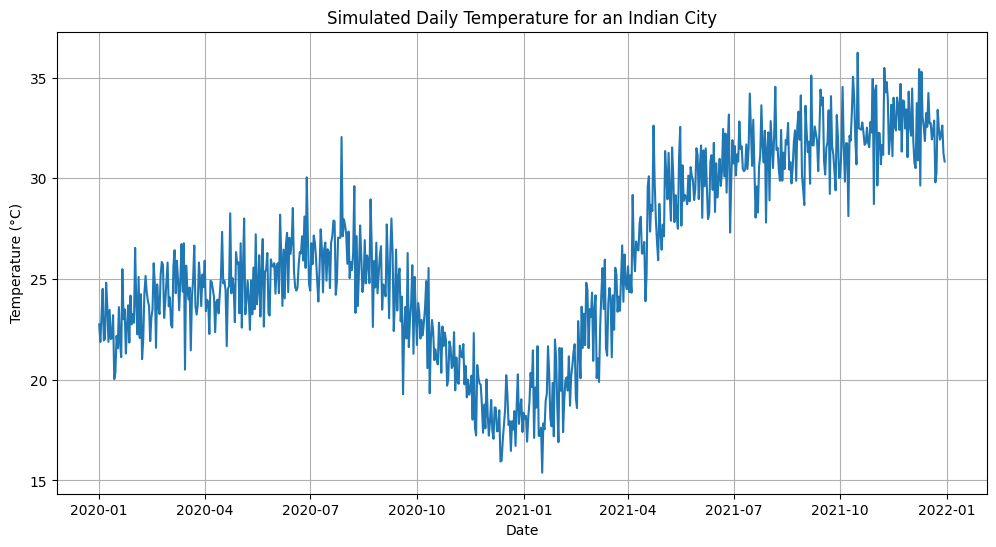

In [16]:
#Session 20
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Simulate daily temperature data for an Indian city
np.random.seed(42)
dates = pd.date_range(start='2020-01-01', periods=365*2, freq='D')
trend = np.linspace(20, 30, len(dates))  # Increasing trend
seasonality = 5 * np.sin(np.linspace(0, 3 * np.pi, len(dates))) + 2 * np.cos(np.linspace(0, 6 * np.pi, len(dates))) # Annual and bi-annual seasonality
noise = np.random.normal(0, 1.5, len(dates))
temperature = trend + seasonality + noise

temp_series = pd.Series(temperature, index=dates)

plt.figure(figsize=(12, 6))
plt.plot(temp_series)
plt.title('Simulated Daily Temperature for an Indian City')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.grid(True)
plt.show()

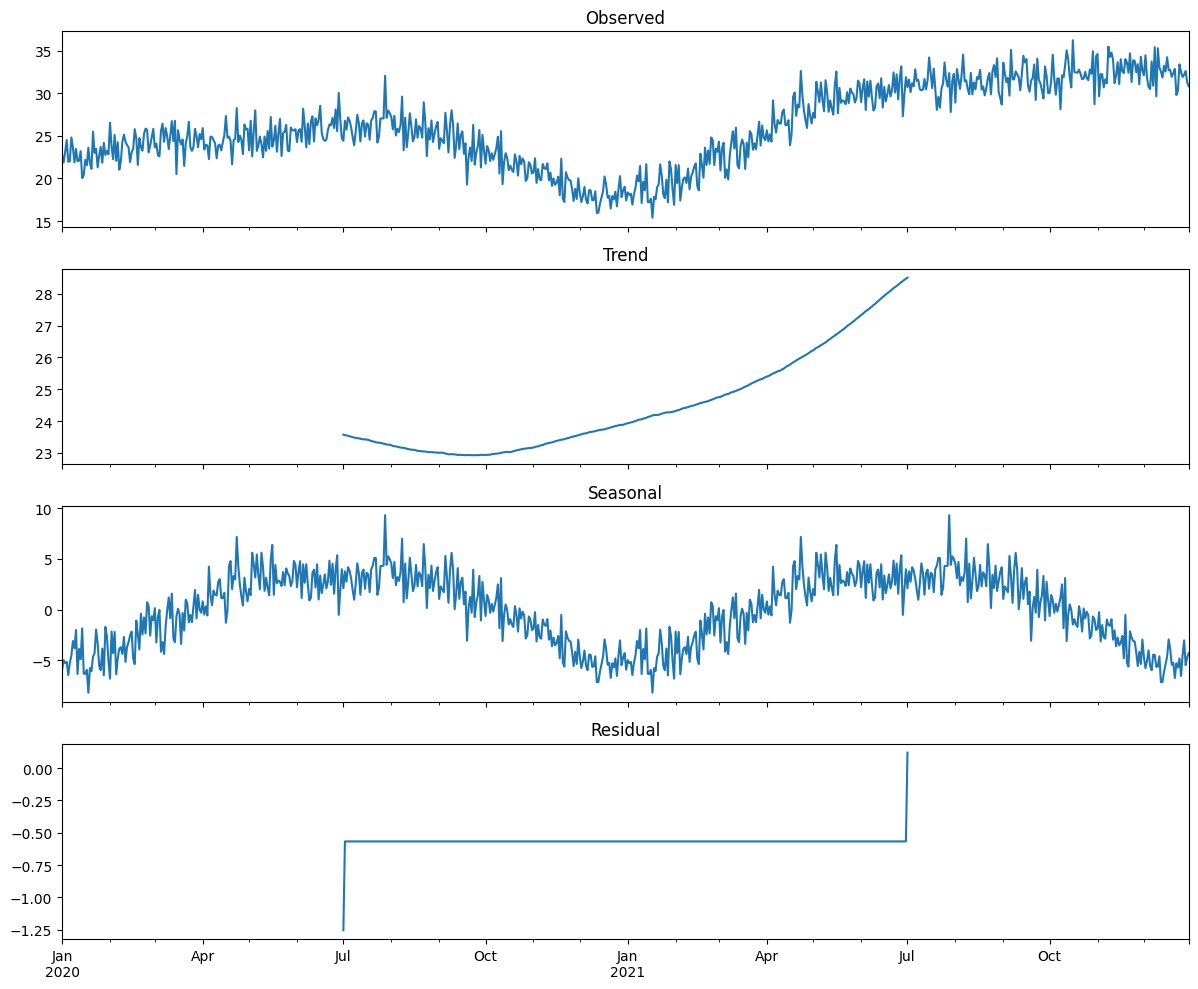

In [17]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(temp_series, model='additive', period=365)

fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

decomposition.observed.plot(ax=ax1, title='Observed')
decomposition.trend.plot(ax=ax2, title='Trend')
decomposition.seasonal.plot(ax=ax3, title='Seasonal')
decomposition.resid.plot(ax=ax4, title='Residual')

plt.tight_layout()
plt.show()

In [18]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(temp_series)
print(f'ADF Statistic: {result[0]:.4f}')
print(f'p-value: {result[1]:.4f}')

ADF Statistic: -0.3895
p-value: 0.9118


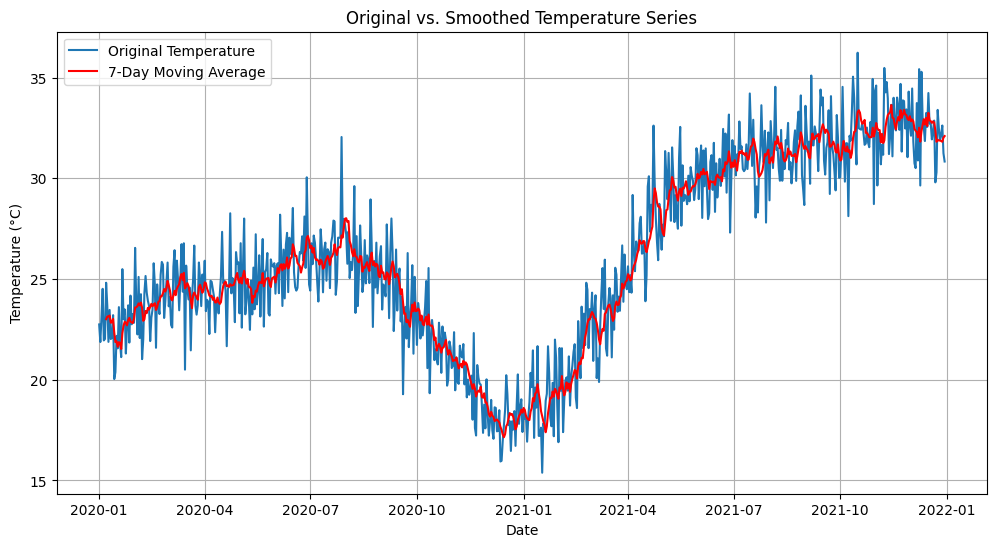

In [19]:
moving_avg = temp_series.rolling(window=7).mean()

plt.figure(figsize=(12, 6))
plt.plot(temp_series, label='Original Temperature')
plt.plot(moving_avg, label='7-Day Moving Average', color='red')
plt.title('Original vs. Smoothed Temperature Series')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

# Assuming (1,1,1) based on visual inspection and potential non-stationarity from ADF
# (p=1 for AR component, d=1 for differencing, q=1 for MA component)
model = ARIMA(temp_series, order=(1,1,1), seasonal_order=(1,0,1,365)) # Added seasonal order for annual pattern
model_fit = model.fit()

forecast_steps = 7
forecast = model_fit.forecast(steps=forecast_steps)

print("Forecasted values for the next 7 days:")
print(forecast)

plt.figure(figsize=(12, 6))
plt.plot(temp_series, label='Original Temperature')
plt.plot(forecast.index, forecast, label='Forecasted Temperature', color='green')
plt.title('Temperature Forecast with ARIMA')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True)
plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


In [ ]:
#session 21
import pandas as pd
import numpy as np

# Create a dummy DataFrame for Ahmedabad daily temperature
dates = pd.date_range(start='2023-01-01', periods=365, freq='D')
temp = np.random.uniform(low=15, high=45, size=365)

# Introduce some seasonality and trend to make it more realistic
temp = temp + 10 * np.sin(np.linspace(0, 2 * np.pi, 365))
temp = temp + np.linspace(-5, 5, 365)

temperature_df = pd.DataFrame({"Date": dates, "Temperature": temp})
temperature_df["Date"] = pd.to_datetime(temperature_df["Date"])
temperature_df = temperature_df.set_index("Date")

temperature_df["Temp_Lag_3"] = temperature_df["Temperature"].shift(3)
temperature_df["Temp_Rolling_7"] = temperature_df["Temperature"].rolling(window=7).mean()

print(temperature_df.head(10))

In [ ]:
import pandas as pd
import numpy as np

# Create a dummy Flipkart-style sales dataset
dates = pd.to_datetime(pd.date_range(start='2023-01-01', periods=1000, freq='H'))
sales = np.random.randint(10, 500, size=1000)

sales_df = pd.DataFrame({"order_date": dates, "sales": sales})

sales_df["day_of_week"] = sales_df["order_date"].dt.dayofweek
sales_df["month"] = sales_df["order_date"].dt.month
sales_df["is_weekend"] = sales_df["order_date"].dt.dayofweek.isin([5, 6]).astype(int)

print(sales_df.head())

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

temp_data = temperature_df.dropna()

X = temp_data[["Temp_Lag_3", "Temp_Rolling_7"]]
y = temp_data["Temperature"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

last_data_point = temperature_df.iloc[-1]
next_day_date = temperature_df.index[-1] + pd.Timedelta(days=1)

# For simplicity, we'll use the last available lag and rolling mean to predict the next day
# In a real scenario, these would need to be calculated based on previous actuals.
next_day_features = pd.DataFrame({
    "Temp_Lag_3": [last_data_point["Temperature"]],
    "Temp_Rolling_7": [temperature_df["Temperature"].iloc[-6:].mean()]
}, index=[next_day_date])

next_day_prediction = model.predict(next_day_features)

print(f"Predicted temperature for {next_day_date.strftime('%Y-%m-%d')}: {next_day_prediction[0]:.2f}°C")

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = mean_absolute_percentage_error(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
print("RMSE is most sensitive to large errors because it squares the errors, amplifying the impact of outliers.")

In [ ]:
def symmetric_mean_absolute_percentage_error(y_true, y_pred):
    numerator = np.abs(y_pred - y_true)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    return np.mean(numerator / denominator) * 100

smape = symmetric_mean_absolute_percentage_error(y_test, y_pred)
print(f"Symmetric Mean Absolute Percentage Error (SMAPE): {smape:.2f}%")
print("I learned that SMAPE handles cases where actual values are zero better than MAPE by using an average in the denominator, which prevents division by zero.")

In [1]:
#session 22
import pandas as pd
import numpy as np

# Simulate Zomato-like dataset
np.random.seed(42)
n_samples = 1000

data = {
    'restaurant_name': [f'Restaurant {i}' for i in range(n_samples)],
    'location': np.random.choice(['Delhi', 'Mumbai', 'Bangalore', 'Pune'], n_samples),
    'cuisine': np.random.choice(['Italian', 'Indian', 'Chinese', 'Mexican', 'Cafe'], n_samples),
    'cost': np.random.randint(100, 2000, n_samples),
    'rating': np.random.normal(3.5, 0.8, n_samples)
}

zomato_df = pd.DataFrame(data)

# Introduce some missing values and outliers for demonstration
zomato_df.loc[np.random.choice(n_samples, 50, replace=False), 'cost'] = np.nan
zomato_df.loc[np.random.choice(n_samples, 30, replace=False), 'rating'] = np.nan
zomato_df.loc[np.random.choice(n_samples, 5, replace=False), 'cost'] = 10000 # Outliers
zomato_df.loc[np.random.choice(n_samples, 5, replace=False), 'rating'] = 5.5 # Outliers

# Clip ratings to a plausible range [0, 5]
zomato_df['rating'] = zomato_df['rating'].clip(0, 5)

print(zomato_df.head())
print(zomato_df.info())
print(zomato_df.describe())

  restaurant_name   location  cuisine    cost    rating
0    Restaurant 0  Bangalore  Italian   242.0  3.532789
1    Restaurant 1       Pune  Italian  1093.0  4.163579
2    Restaurant 2      Delhi  Italian   205.0       NaN
3    Restaurant 3  Bangalore     Cafe   986.0  3.791419
4    Restaurant 4  Bangalore  Mexican   527.0  2.836770
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   restaurant_name  1000 non-null   object 
 1   location         1000 non-null   object 
 2   cuisine          1000 non-null   object 
 3   cost             950 non-null    float64
 4   rating           970 non-null    float64
dtypes: float64(2), object(3)
memory usage: 39.2+ KB
None
               cost      rating
count    950.000000  970.000000
mean    1100.804211    3.524575
std      845.129153    0.771602
min      101.000000    0.790549
25%      578.000000

In [2]:
import numpy as np

# Handle missing values
zomato_df['cost'].fillna(zomato_df['cost'].median(), inplace=True)
zomato_df['rating'].fillna(zomato_df['rating'].mean(), inplace=True)

# Handle outliers in 'cost' using IQR method
Q1_cost = zomato_df['cost'].quantile(0.25)
Q3_cost = zomato_df['cost'].quantile(0.75)
IQR_cost = Q3_cost - Q1_cost
upper_bound_cost = Q3_cost + 1.5 * IQR_cost
lower_bound_cost = Q1_cost - 1.5 * IQR_cost
zomato_df['cost'] = np.where(zomato_df['cost'] > upper_bound_cost, upper_bound_cost, zomato_df['cost'])
zomato_df['cost'] = np.where(zomato_df['cost'] < lower_bound_cost, lower_bound_cost, zomato_df['cost'])

# For 'rating', since it's already clipped to 0-5 and we're filling NaNs with mean,
# strong outliers (outside 0-5) are unlikely, but we can verify reasonable range.
# If there were any, clipping would be an appropriate strategy.

print(zomato_df.isnull().sum())
print(zomato_df[['cost', 'rating']].describe())

restaurant_name    0
location           0
cuisine            0
cost               0
rating             0
dtype: int64
              cost       rating
count  1000.000000  1000.000000
mean   1063.288375     3.524575
std     544.219721     0.759928
min     101.000000     0.790549
25%     596.750000     3.007379
50%    1065.000000     3.524575
75%    1500.000000     4.040073
max    2854.875000     5.000000


/tmp/ipykernel_9883/638846551.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  zomato_df['cost'].fillna(zomato_df['cost'].median(), inplace=True)
/tmp/ipykernel_9883/638846551.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inpl

In [6]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
import pandas as pd

# Define categorical and numerical features
categorical_features = ['cuisine', 'location']
numerical_features = ['cost', 'rating']

# Select only the relevant columns from zomato_df to pass to the preprocessor
features_to_process_df = zomato_df[categorical_features + numerical_features]

# Create a column transformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', StandardScaler(), numerical_features)
    ],
    remainder='drop'
)

# Apply transformations
X_processed = preprocessor.fit_transform(features_to_process_df)

# Get feature names after one-hot encoding for categorical features
onehot_features = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
all_features = list(onehot_features) + numerical_features

print(f"Shape of X_processed after ColumnTransformer: {X_processed.shape}")
print(f"Number of column names generated: {len(all_features)}")

X_processed_df = pd.DataFrame(X_processed, columns=all_features)

print(X_processed_df.head())

Shape of X_processed after ColumnTransformer: (1000, 11)
Number of column names generated: 11
   cuisine_Cafe  cuisine_Chinese  cuisine_Indian  cuisine_Italian  \
0           0.0              0.0             0.0              1.0   
1           0.0              0.0             0.0              1.0   
2           0.0              0.0             0.0              1.0   
3           1.0              0.0             0.0              0.0   
4           0.0              0.0             0.0              0.0   

   cuisine_Mexican  location_Bangalore  location_Delhi  location_Mumbai  \
0              0.0                 1.0             0.0              0.0   
1              0.0                 0.0             0.0              0.0   
2              0.0                 0.0             1.0              0.0   
3              0.0                 1.0             0.0              0.0   
4              1.0                 1.0             0.0              0.0   

   location_Pune      cost        rating

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

# Define the target variable: rating above 4.0
zomato_df['high_rating'] = (zomato_df['rating'] > 4.0).astype(int)
y = zomato_df['high_rating']

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42, stratify=y)

# Train Logistic Regression model
log_reg = LogisticRegression(random_state=42, solver='liblinear')
log_reg.fit(X_train, y_train)
log_reg_pred_proba = log_reg.predict_proba(X_test)[:, 1]
log_reg_roc_auc = roc_auc_score(y_test, log_reg_pred_proba)

# Train Random Forest model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
rf_pred_proba = rf_model.predict_proba(X_test)[:, 1]
rf_roc_auc = roc_auc_score(y_test, rf_pred_proba)

print(f"Logistic Regression ROC-AUC: {log_reg_roc_auc:.4f}")
print(f"Random Forest ROC-AUC: {rf_roc_auc:.4f}")

if rf_roc_auc > log_reg_roc_auc:
    print("Random Forest performed better.")
else:
    print("Logistic Regression performed better.")

Logistic Regression ROC-AUC: 0.9977
Random Forest ROC-AUC: 1.0000
Random Forest performed better.


In [8]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline # Avoid conflict with sklearn Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

# Check class distribution of the target variable
print(f"Original class distribution: {y_train.value_counts()}")

# Create a pipeline with SMOTE and RandomForestClassifier
pipeline_smote_rf = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(random_state=42))
])

# Define parameter grid for GridSearchCV
param_grid = {
    'classifier__n_estimators': [50, 100, 150],
    'classifier__max_depth': [10, 20, None]
}

# Perform GridSearchCV
grid_search_smote = GridSearchCV(pipeline_smote_rf, param_grid, cv=3, scoring='roc_auc', n_jobs=-1)
grid_search_smote.fit(X_train, y_train)

# Print best parameters and ROC-AUC score
print(f"Best parameters with SMOTE and GridSearchCV: {grid_search_smote.best_params_}")

best_rf_model = grid_search_smote.best_estimator_
best_rf_pred_proba = best_rf_model.predict_proba(X_test)[:, 1]
best_rf_roc_auc = roc_auc_score(y_test, best_rf_pred_proba)

print(f"Best ROC-AUC score with SMOTE and GridSearchCV: {best_rf_roc_auc:.4f}")

Original class distribution: high_rating
0    586
1    214
Name: count, dtype: int64
Best parameters with SMOTE and GridSearchCV: {'classifier__max_depth': 10, 'classifier__n_estimators': 50}
Best ROC-AUC score with SMOTE and GridSearchCV: 1.0000
